In [21]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import time
from collections import OrderedDict

# 修改参数设置 - double soliton参数
a = 0.3  # Klein-Gordon方程系数
b = 1    # 非线性系数
c1 = 0.25   # 第一个孤立子速度
c2 = -0.25  # 第二个孤立子速度
k1 = np.sqrt(a / (2 * (a**2 - c1**2)))  # 第一个波数
k2 = np.sqrt(a / (2 * (a**2 - c2**2)))  # 第二个波数

nu = 0.1

In [22]:
# 修改精确解函数 - double soliton形式
def analytical_solution(t, x):
    """
    Klein-Gordon方程精确解 (double soliton形式)
    u(x,t) = sqrt(2a/b) * sech(k1*(x - c1*t + 2)) + sqrt(2a/b) * sech(k2*(x - c2*t - 2))
    """
    sech_term1 = 1.0 / torch.cosh(k1 * (x - c1 * t + 2))
    sech_term2 = 1.0 / torch.cosh(k2 * (x - c2 * t - 2))
    u = torch.sqrt(torch.tensor(2*a/b)) * (sech_term1 + sech_term2)
    return u.reshape(-1, 1)

def analytical_solution_v(t, x):
    """
    v = du/dt 的精确解 (double soliton形式)
    v(x,t) = c1*k1*sqrt(2a/b)*sech(k1*(x-c1*t+2))*tanh(k1*(x-c1*t+2)) +
             c2*k2*sqrt(2a/b)*sech(k2*(x-c2*t-2))*tanh(k2*(x-c2*t-2))
    """
    # 第一个孤立子的贡献
    sech_term1 = 1.0 / torch.cosh(k1 * (x - c1 * t + 2))
    tanh_term1 = torch.tanh(k1 * (x - c1 * t + 2))
    v1 = c1 * k1 * torch.sqrt(torch.tensor(2*a/b)) * sech_term1 * tanh_term1
    
    # 第二个孤立子的贡献
    sech_term2 = 1.0 / torch.cosh(k2 * (x - c2 * t - 2))
    tanh_term2 = torch.tanh(k2 * (x - c2 * t - 2))
    v2 = c2 * k2 * torch.sqrt(torch.tensor(2*a/b)) * sech_term2 * tanh_term2
    
    v = v1 + v2
    return v.reshape(-1, 1)

def initial_condition_u(x):
    """初始条件 u(x,0) = sqrt(2a/b) * (sech(k1*(x+2)) + sech(k2*(x-2)))"""
    sech_term1 = 1.0 / torch.cosh(k1 * (x + 2))
    sech_term2 = 1.0 / torch.cosh(k2 * (x - 2))
    return torch.sqrt(torch.tensor(2*a/b)) * (sech_term1 + sech_term2)

def initial_condition_v(x):
    """初始条件 v(x,0) = c1*k1*sqrt(2a/b)*sech(k1*(x+2))*tanh(k1*(x+2)) +
                           c2*k2*sqrt(2a/b)*sech(k2*(x-2))*tanh(k2*(x-2))"""
    # 第一个孤立子的贡献
    sech_term1 = 1.0 / torch.cosh(k1 * (x + 2))
    tanh_term1 = torch.tanh(k1 * (x + 2))
    v1 = c1 * k1 * torch.sqrt(torch.tensor(2*a/b)) * sech_term1 * tanh_term1
    
    # 第二个孤立子的贡献
    sech_term2 = 1.0 / torch.cosh(k2 * (x - 2))
    tanh_term2 = torch.tanh(k2 * (x - 2))
    v2 = c2 * k2 * torch.sqrt(torch.tensor(2*a/b)) * sech_term2 * tanh_term2
    
    return v1 + v2

In [23]:
class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 2)  # 输出2个变量：u和v
        self.tanh = nn.Tanh()
        self.iter = 0

    def forward(self, x, t=None):
        if t is not None:
            # 分开的x和t作为输入
            inputs = torch.cat([t, x], dim=1)  # 注意顺序是[t,x]
        else:
            # 已经组合的输入
            inputs = x
            
        out = self.linear1(inputs)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        out = self.tanh(out)
        out = self.output(out)
        return out  # 返回[u, v]

In [24]:
# 从sampling_PDE.py引入的DNN类
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

# MMPDE采样类
class sampling_MMPDE():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        # 边界条件
        self.lb = torch.tensor(lb).float()
        self.ub = torch.tensor(ub).float()

        # 数据
        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float()
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float()
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        # 深度神经网络
        self.dnn = DNN(layers)

        # 优化器设置
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, u, t, x):

        # 计算u对t的一阶导数
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对t的二阶导数(utt)
        u_tt = torch.autograd.grad(
            u_t, t,
            grad_outputs=torch.ones_like(u_t),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对x的一阶导数
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # 计算u对x的二阶导数(uxx)
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # w = (1 + u_xx ** 2 + u_tt ** 2) ** (1 / 2)
        # w = (1 + (0.3 * u_xx ** 2) + (0.4 * u_tt ** 2)) ** (1 / 2)
        w = 0.5 * (u_t ** 2 - a **2 * u_x ** 2 + a * u ** 2 - b/2 * u ** 4)
        # w = (1 + u_x ** 2) ** (1 / 2)  
        
        return w

    def net_sample(self, t, x):
        # 生成新的采样点
        xNew = self.dnn(torch.cat([t, x], dim=1))
        g0 = x - self.lb[1]
        g1 = x - self.ub[1]
        xNew = g0*g1*xNew + x
        return xNew

    def net_f(self, t, x):
        # 计算MMPDE方程的残差
        xNew = self.net_sample(t, x)

        xNew_t = torch.autograd.grad(
            xNew, t,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]

        xNew_x = torch.autograd.grad(
            xNew, x,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]
        
        xNew_xx = torch.autograd.grad(
            xNew_x, x,
            grad_outputs=torch.ones_like(xNew_x),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算解及其导数
        u = self.fun(torch.cat([t, x], dim=1))
        
        # 直接调用修改后的monitor函数，传入u,t,x
        G = self.monitor(u, t, x)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # 不再需要G_tx的计算，因为我们已经在monitor函数中处理了二阶导数

        E = G_x * xNew_x + G * xNew_xx
        f = xNew_t*self.nu*(G**2)*(xNew_x**2) + E

        return f

    def loss_func(self):
        # 计算损失函数
        f_pred = self.net_f(self.t_f, self.x_f)
        loss_f = torch.mean(f_pred ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        # 损失函数初始化
        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        # 训练过程
        print("开始MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('MMPDE_LBGFS 完成!')

        # 返回新的采样点
        new_x = self.net_sample(self.t_f, self.x_f)
        new_sample = torch.cat([self.t_f, new_x], dim=1)
        return new_sample

In [25]:
def create_simulation_function_from_model(model):
    """基于当前PINN模型创建模拟函数，用于MMPDE采样"""
    def simulation_function(xt):
        model.eval()  # 设置为评估模式
        # 注意：不使用torch.no_grad()，因为MMPDE需要计算梯度
        
        # 确保输入张量需要梯度
        if not xt.requires_grad:
            xt.requires_grad_(True)
            
        return model(xt)
    return simulation_function

In [26]:
def x_f_loss_fun(inputs, model):
    """
    计算Klein-Gordon方程PDE残差（一阶系统形式）:
    du/dt = v
    dv/dt = a^2 * u_xx - a * u + b * u^3
    """
    if not inputs.requires_grad:
        inputs = Variable(inputs, requires_grad=True)
    
    # 获取模型预测的u和v
    outputs = model(inputs)
    u = outputs[:, 0:1]  # 第一个输出是u
    v = outputs[:, 1:2]  # 第二个输出是v
    
    # 提取坐标
    t = inputs[:, 0:1]
    x = inputs[:, 1:2]
    
    # 计算u关于输入的梯度
    u_grad = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grad[:, 0:1]  # du/dt
    u_x = u_grad[:, 1:2]  # du/dx
    
    # 计算v关于输入的梯度
    v_grad = torch.autograd.grad(v, inputs, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_t = v_grad[:, 0:1]  # dv/dt
    
    # 计算u_xx - 对u_x再求一次关于x的导数
    u_xx = torch.autograd.grad(u_x, inputs, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]
    
    # 计算PDE残差
    # 第一个方程：du/dt = v
    f1 = u_t - v
    
    # 第二个方程：dv/dt = a^2 * u_xx - a * u + b * u^3
    f2 = v_t - (a**2 * u_xx - a * u + b * (u**3))
    
    return torch.cat([f1, f2], dim=1)

In [27]:
# 修改边界条件函数 - double soliton使用齐次Neumann边界条件
def boundary_loss(model, x_bc):
    """
    边界条件损失：double soliton的齐次Neumann边界条件
    u_x(-10, t) = u_x(10, t) = 0
    """
    inputs = x_bc.clone().requires_grad_(True)
    outputs = model(inputs)
    u = outputs[:, 0:1]  # 获取u
    
    # 计算u_x
    u_x = torch.autograd.grad(
        u, inputs,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0][:, 1:2]  # 对x的导数
    
    # 齐次Neumann边界条件：u_x = 0 在边界处
    return torch.mean(u_x**2)

def initial_condition_loss(model, x_ic):
    """
    初始条件损失：
    1. u(x,0) = sqrt(2a/b) * sech(kx)
    2. v(x,0) = c * k * sqrt(2a/b) * sech(kx) * tanh(kx)
    """
    outputs = model(x_ic)
    u_pred = outputs[:, 0:1]
    v_pred = outputs[:, 1:2]
    
    # 提取x坐标
    x = x_ic[:, 1:2]
    
    # 计算初始条件目标值
    u_ic_target = initial_condition_u(x)
    v_ic_target = initial_condition_v(x)
    
    # 计算损失
    u_loss = torch.mean((u_pred - u_ic_target)**2)
    v_loss = torch.mean((v_pred - v_ic_target)**2)
    
    return u_loss + v_loss

开始执行迭代训练...
开始迭代训练：PINN + MMPDE 自适应采样

【第一阶段】使用均匀采样进行初始训练 (3000 epochs)
生成等距网格点: 70×71 = 4970个点
开始初始训练...
Epoch [1/3000], Loss: 8.418738e-01, PDE: 1.492968e-02, BC: 7.996295e-06, IC: 8.268641e-02
Epoch [501/3000], Loss: 6.728356e-02, PDE: 1.815194e-03, BC: 3.351195e-05, IC: 6.513325e-03
Epoch [1001/3000], Loss: 1.876690e-02, PDE: 8.816788e-04, BC: 8.943668e-07, IC: 1.787628e-03
Epoch [1501/3000], Loss: 4.640157e-03, PDE: 7.815817e-04, BC: 1.159676e-05, IC: 3.742608e-04
Epoch [2001/3000], Loss: 3.816004e-03, PDE: 6.114742e-04, BC: 9.909915e-06, IC: 3.105431e-04
Epoch [2501/3000], Loss: 1.575858e-03, PDE: 5.452273e-04, BC: 8.044552e-06, IC: 9.501851e-05
初始训练完成，当前损失: 1.116939e-03
生成等距网格点: 70×71 = 4970个点
初始化MMPDE采样点: 4970个均匀分布点

【第2阶段】迭代 1: MMPDE自适应采样 + 继续训练
基于当前PINN模型进行MMPDE自适应采样...
使用 4970 个采样点作为MMPDE的输入点
开始MMPDE训练...
MMPDE_Adam Iter 100, Loss: 0.000025
Time: 6.7048s
MMPDE_Adam Iter 200, Loss: 0.000011
Time: 6.9070s
MMPDE_Adam 完成!
MMPDE_LBFGS Iter 300, Loss: 0.000002
Time: 6.8708s
MMPDE_

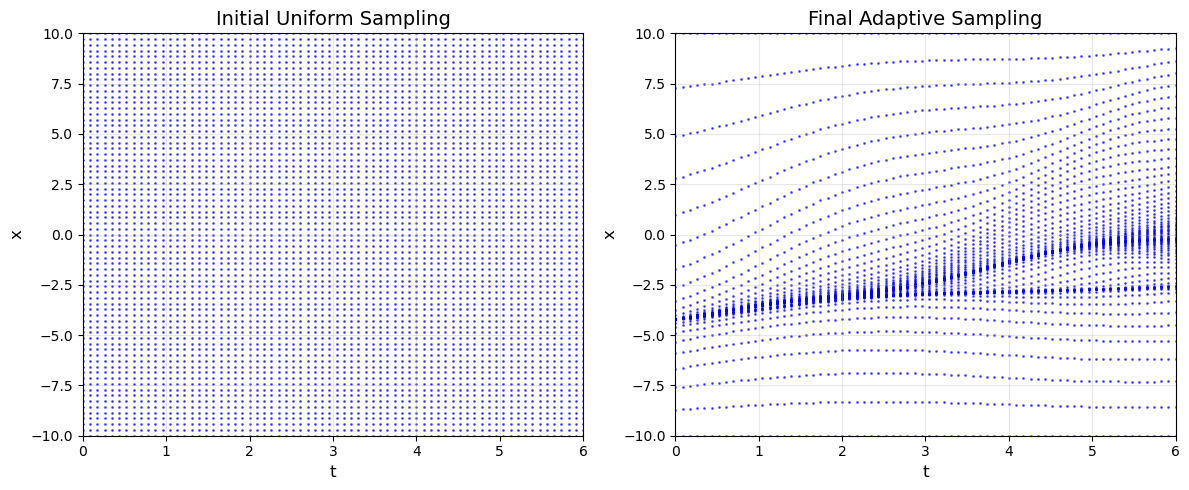


迭代训练完成！


In [28]:
def generate_uniform_grid_points(n_points=1000, for_mmpde=False):

    # 计算每个维度的点数
    n_t = int(np.sqrt(n_points)) 
    n_x = int(n_points / n_t) 
    
    # 生成等距采样点
    t_uniform = torch.linspace(0, 6, n_t)
    x_uniform = torch.linspace(-10, 10, n_x)
    
    # 创建网格
    T_grid, X_grid = torch.meshgrid(t_uniform, x_uniform, indexing='ij')
    
    # 展平并转换为列向量
    t_flat = T_grid.reshape(-1, 1)
    x_flat = X_grid.reshape(-1, 1)
    
    print(f"生成等距网格点: {n_t}×{n_x} = {t_flat.shape[0]}个点")
    
    if for_mmpde:
        # 用于MMPDE，返回numpy数组
        combined = torch.cat([t_flat, x_flat], dim=1).numpy()
        return combined
    else:
        # 用于PINN训练，返回需要梯度的torch张量
        t_flat.requires_grad_(True)
        x_flat.requires_grad_(True)
        return t_flat, x_flat

def generate_boundary_condition_points(n_points=1000):
    """生成边界条件点"""
    t_bc = torch.rand(n_points, 1) * 6.0  # t ∈ [0, 12]
    x_bc_left = torch.full((n_points//2, 1), -10.0)  # x = -10
    x_bc_right = torch.full((n_points//2, 1), 10.0)  # x = 10
    
    t_bc_split = torch.split(t_bc, n_points//2)
    x_bc_left_combined = torch.cat([t_bc_split[0], x_bc_left], dim=1)
    x_bc_right_combined = torch.cat([t_bc_split[1], x_bc_right], dim=1)
    x_bc_combined = torch.cat([x_bc_left_combined, x_bc_right_combined], dim=0)
    x_bc_combined.requires_grad_(True)
    
    return x_bc_combined

def generate_initial_condition_points(n_points=1000):
    """生成初始条件点"""
    x_ic = torch.rand(n_points, 1) * 20 - 10  # x ∈ [-10, 10]
    t_ic = torch.zeros(n_points, 1)
    x_ic_combined = torch.cat([t_ic, x_ic], dim=1)
    x_ic_combined.requires_grad_(True)
    
    return x_ic_combined

def generate_initial_training_data():
    """生成初始训练数据（均匀采样）"""
    # 均匀配点
    t_colloc, x_colloc = generate_uniform_grid_points(n_points=5000, for_mmpde=False)
    x_colloc_combined = torch.cat([t_colloc, x_colloc], dim=1)
    
    # 边界条件点
    x_bc_combined = generate_boundary_condition_points(n_points=1000)
    
    # 初始条件点
    x_ic_combined = generate_initial_condition_points(n_points=1000)
    
    return x_colloc_combined, x_bc_combined, x_ic_combined

def iterative_training_with_adaptive_sampling(
    initial_epochs=3000,      # 初始训练轮数
    adaptive_epochs=2000,     # 每次自适应采样后的训练轮数  
    num_iterations=3,         # 迭代次数
    mmpde_training_epochs=1000 # MMPDE训练轮数
):
    """
    迭代训练策略：
    1. 用均匀采样训练初始PINN模型
    2. 基于当前模型进行MMPDE自适应采样
    3. 用新的采样点继续训练PINN
    4. 重复步骤2-3
    """
    
    print("=" * 80)
    print("开始迭代训练：PINN + MMPDE 自适应采样")
    print("=" * 80)
    
    # ==================== 第一阶段：初始训练 ====================
    print(f"\n【第一阶段】使用均匀采样进行初始训练 ({initial_epochs} epochs)")
    
    # 创建初始模型
    model = PINN(2, 40)  # 输入维度是2 (t和x)，隐藏层维度40
    model.iter = 0
    
    # 初始训练数据
    x_colloc_combined, x_bc_combined, x_ic_combined = generate_initial_training_data()
    
    # 优化器
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.5)
    
    # 记录初始和最终采样点
    sampling_points_history = []
    
    # 保存初始均匀采样点
    initial_samples = x_colloc_combined.detach().cpu().numpy()
    sampling_points_history.append(("Initial Uniform Sampling", initial_samples))
    
    # 初始训练
    print("开始初始训练...")
    for epoch in range(initial_epochs):
        optimizer_adam.zero_grad()

        f = x_f_loss_fun(x_colloc_combined, model)
        loss_pde = torch.mean(f**2)
        loss_bc = boundary_loss(model, x_bc_combined)
        loss_ic = initial_condition_loss(model, x_ic_combined)
        total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
        total_loss.backward()
        
        # 添加梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer_adam.step()
        scheduler.step()
        model.iter += 1
        
        if epoch % 500 == 0:
            print(f"Epoch [{epoch+1}/{initial_epochs}], "
                  f"Loss: {total_loss.item():.6e}, "
                  f"PDE: {loss_pde.item():.6e}, "
                  f"BC: {loss_bc.item():.6e}, "
                  f"IC: {loss_ic.item():.6e}")
    
    print(f"初始训练完成，当前损失: {total_loss.item():.6e}")
    
    # ==================== 初始化MMPDE采样点 ====================
    # 使用统一函数生成MMPDE初始采样点
    X_f_current = generate_uniform_grid_points(n_points=5000, for_mmpde=True)
    print(f"初始化MMPDE采样点: {X_f_current.shape[0]}个均匀分布点")
    
    # ==================== 迭代阶段：MMPDE + 继续训练 ====================
    final_samples = None  # 用于存储最终采样点
    
    for iteration in range(num_iterations):
        print(f"\n【第{iteration+2}阶段】迭代 {iteration+1}: MMPDE自适应采样 + 继续训练")
        
        # 基于当前模型进行MMPDE采样
        print("基于当前PINN模型进行MMPDE自适应采样...")
        print(f"使用 {X_f_current.shape[0]} 个采样点作为MMPDE的输入点")
        
        # 使用当前模型创建模拟函数
        current_sim_func = create_simulation_function_from_model(model)
        
        # MMPDE参数
        mmpde_layers = [2, 20, 20, 20, 1]
        adam_iter = mmpde_training_epochs // 2
        lbfgs_iter = mmpde_training_epochs // 4
        
        # 创建MMPDE采样器 - 使用当前采样点
        mmpde_sampler = sampling_MMPDE(
            X_f=X_f_current,  # 使用上一次的采样点
            u_fun=current_sim_func,
            layers=mmpde_layers,
            lb=[0.0, -10.0],  # [t_min, x_min]
            ub=[6.0, 10.0],  # [t_max, x_max]
            nu=0.001,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter
        )
        
        # 训练MMPDE并获取新采样点
        new_samples = mmpde_sampler.train()
        
        # 更新当前采样点为新的采样点，用于下一次迭代
        X_f_current = new_samples.detach().cpu().numpy()
        final_samples = X_f_current.copy()  # 保存作为最终结果
        
        # 提取新的配点用于PINN训练
        t_colloc_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
        x_colloc_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
        x_colloc_combined = torch.cat([t_colloc_new, x_colloc_new], dim=1)
        
        print(f"获得新的自适应采样点: {new_samples.shape[0]}个")
        
        # 使用新采样点继续训练
        print(f"使用新采样点继续训练 ({adaptive_epochs} epochs)...")
        for epoch in range(adaptive_epochs):
            optimizer_adam.zero_grad()
            
            # 计算PDE残差
            f = x_f_loss_fun(x_colloc_combined, model)
            loss_pde = torch.mean(f**2)
            
            # 计算边界条件损失
            loss_bc = boundary_loss(model, x_bc_combined)
            
            # 计算初始条件损失
            loss_ic = initial_condition_loss(model, x_ic_combined)
            
            # 总损失
            total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
            
            total_loss.backward()
            
            # 添加梯度裁剪
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer_adam.step()
            model.iter += 1
            
            if (epoch + 1) % 400 == 0:
                print(f"Epoch [{epoch+1}/{adaptive_epochs}], Loss: {total_loss.item():.6e}")
        
        print(f"迭代 {iteration+1} 完成，当前损失: {total_loss.item():.6e}")
    
    # 保存最终采样点
    if final_samples is not None:
        sampling_points_history.append(("Final Adaptive Sampling", final_samples))
    
    # ==================== 可视化采样点演化 ====================
    print("\n正在生成采样点对比可视化...")
    visualize_sampling_evolution(sampling_points_history)
    
    print("\n" + "=" * 80)
    print("迭代训练完成！")
    print("=" * 80)
    
    return model, sampling_points_history

def visualize_sampling_evolution(sampling_points_history, n_display_points=5000):
    """
    可视化初始和最终采样点的对比
    """
    n_plots = len(sampling_points_history)
    
    # 创建子图
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
    
    if n_plots == 1:
        axes = [axes]
    
    for plot_idx, (title, points) in enumerate(sampling_points_history):
        # 随机采样以避免图像过于密集
        if len(points) > n_display_points:
            indices = np.random.choice(len(points), n_display_points, replace=False)
            display_points = points[indices]
        else:
            display_points = points
        
        # 绘制散点图
        scatter = axes[plot_idx].scatter(display_points[:, 0], display_points[:, 1], 
                           c='blue', s=1, alpha=0.6)
        
        axes[plot_idx].set_xlim(0, 6)
        axes[plot_idx].set_ylim(-10, 10)
        axes[plot_idx].set_xlabel('t', fontsize=12)
        axes[plot_idx].set_ylabel('x', fontsize=12)
        axes[plot_idx].set_title(title, fontsize=14)
        axes[plot_idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 执行迭代训练
print("开始执行迭代训练...")
trained_model, sampling_history = iterative_training_with_adaptive_sampling(
    initial_epochs=3000,      # 初始训练轮数
    adaptive_epochs=2000,     # 每次自适应后的训练轮数
    num_iterations=2,         # 迭代次数
    mmpde_training_epochs=500 # MMPDE训练轮数
)

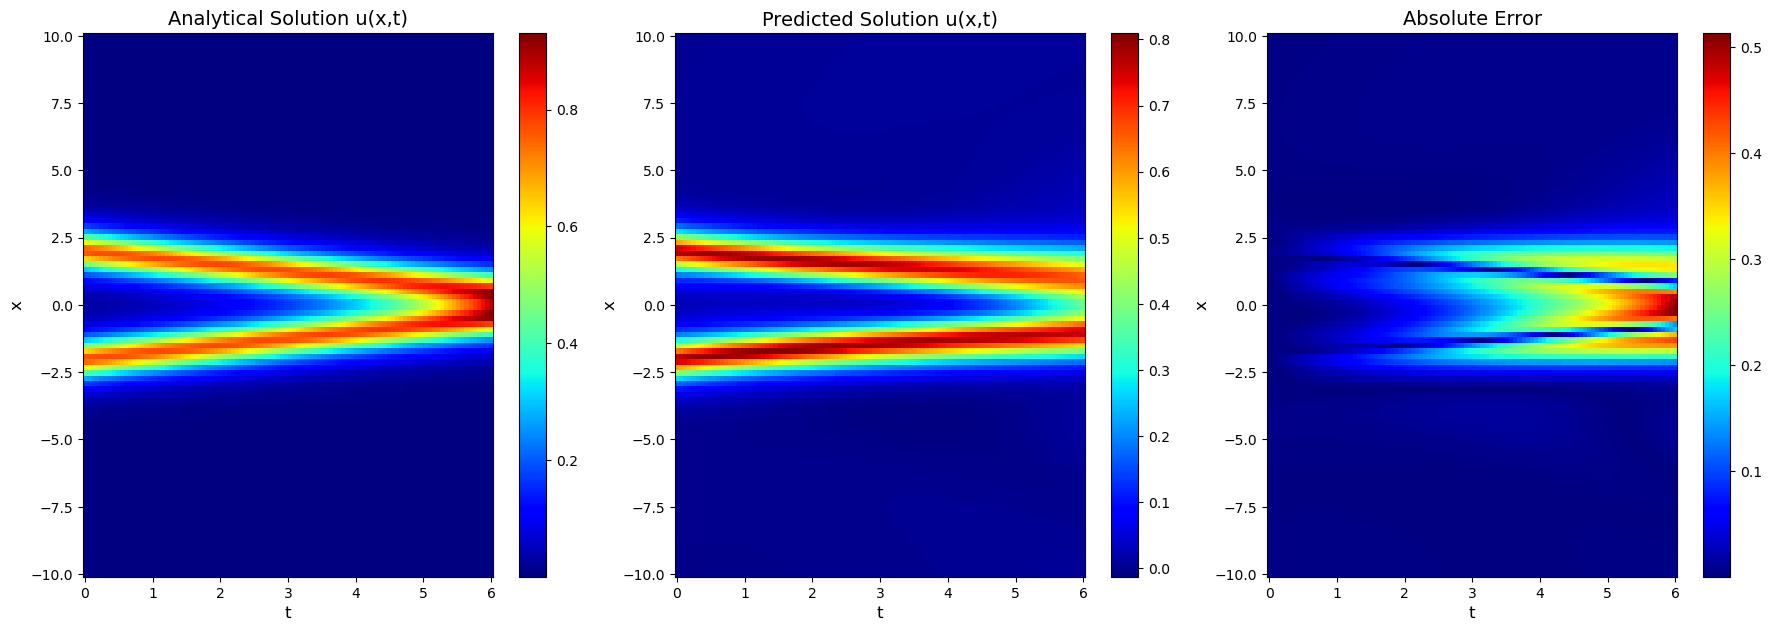

u的L2误差: 0.092336
v的L2误差: 0.044097


In [29]:
# 修改可视化部分 - 更新网格范围到[0, 10]
# 创建网格点
nx, nt = 100, 100
x = torch.linspace(-10, 10, nx).reshape(-1, 1)  # x范围[-10,10]
t = torch.linspace(0, 6, nt).reshape(-1, 1)   # t范围改为[0,10]

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

# 组合输入
X_test = torch.cat([T_flat, X_flat], dim=1)

# 模型预测
with torch.no_grad():
    outputs_pred = trained_model(X_test)
    u_pred = outputs_pred[:, 0:1].reshape(nx, nt).detach().numpy()
    v_pred = outputs_pred[:, 1:2].reshape(nx, nt).detach().numpy()

# 解析解
u_exact = analytical_solution(T_flat, X_flat).reshape(nx, nt).detach().numpy()
v_exact = analytical_solution_v(T_flat, X_flat).reshape(nx, nt).detach().numpy()

# 计算误差
u_error = np.abs(u_pred - u_exact)
v_error = np.abs(v_pred - v_exact)

# 显示热图对比（现在显示u和v）
plt.figure(figsize=(18, 12))

# u的对比
plt.subplot(231)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_exact, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Analytical Solution u(x,t)', fontsize=14)

plt.subplot(232)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_pred, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Predicted Solution u(x,t)', fontsize=14)

plt.subplot(233)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_error, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Absolute Error', fontsize=14)

plt.tight_layout()
plt.show()

# 计算L2误差
total_u_l2_error = np.sqrt(np.mean(np.square(u_pred - u_exact)))
total_v_l2_error = np.sqrt(np.mean(np.square(v_pred - v_exact)))
print(f"u的L2误差: {total_u_l2_error:.6f}")
print(f"v的L2误差: {total_v_l2_error:.6f}")

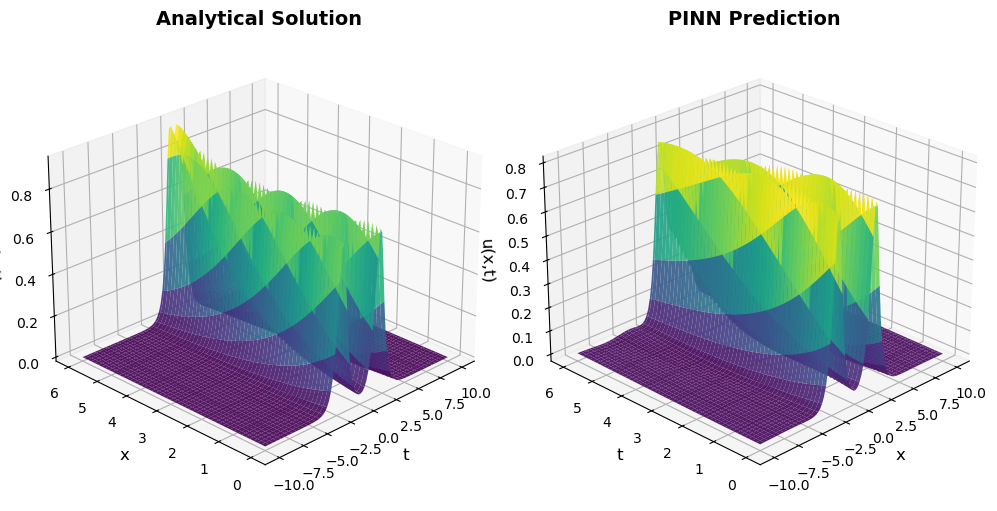

In [30]:
# 创建单独的大图显示u的三维对比
fig = plt.figure(figsize=(15, 5))

# 解析解
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf1 = ax1.plot_surface(X.numpy(), T.numpy(), u_exact, 
                        cmap='viridis', alpha=0.9, linewidth=0.5, 
                        antialiased=True, linestyle='--')
ax1.set_xlabel('t', fontsize=12)
ax1.set_ylabel('x', fontsize=12)
ax1.set_zlabel('u(x,t)', fontsize=12)
ax1.set_title('Analytical Solution', fontsize=14, fontweight='bold')
ax1.view_init(elev=25, azim=45)
# 移除colorbar

# 设置坐标轴反向
ax1.invert_xaxis()  # t轴反向：从12到0
ax1.invert_yaxis()  # x轴反向：从10到-10

# PINN预测解
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X.numpy(), T.numpy(), u_pred, 
                        cmap='viridis', alpha=0.9, linewidth=0.5, 
                        antialiased=True, linestyle='--')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('t', fontsize=12)
ax2.set_zlabel('u(x,t)', fontsize=12)
ax2.set_title('PINN Prediction', fontsize=14, fontweight='bold')
ax2.view_init(elev=25, azim=45)
# 移除colorbar

# 设置坐标轴反向
ax2.invert_xaxis()  # t轴反向：从12到0
ax2.invert_yaxis()  # x轴反向：从10到-10

plt.tight_layout()
plt.show()

In [31]:
# 绘制不同时间点的解的切片对比
def plot_time_slices():
    """绘制不同时间点的解的切片对比"""
    time_points = [0, 1, 2, 3, 4, 5]  # 修改时间点
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    x_slice = torch.linspace(-10, 10, 200).reshape(-1, 1)
    
    for i, t_val in enumerate(time_points):
        if i >= 6:  # 只有6个子图
            break
            
        t_slice = torch.full_like(x_slice, t_val)
        x_test_slice = torch.cat([t_slice, x_slice], dim=1)
        
        # 模型预测
        with torch.no_grad():
            outputs_slice = trained_model(x_test_slice)
            u_pred_slice = outputs_slice[:, 0:1].detach().numpy()
        
        # 解析解
        u_exact_slice = analytical_solution(t_slice, x_slice).detach().numpy()
        
        # 绘制对比
        axes[i].plot(x_slice.numpy(), u_exact_slice, 'b-', linewidth=2, label='Analytical')
        axes[i].plot(x_slice.numpy(), u_pred_slice, 'r--', linewidth=2, label='PINN')
        axes[i].set_xlabel('x', fontsize=12)
        axes[i].set_ylabel('u(x,t)', fontsize=12)
        axes[i].set_title(f't = {t_val}', fontsize=14)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
        
        # 计算该时间点的误差
        error_slice = np.abs(u_pred_slice - u_exact_slice)
        max_error = np.max(error_slice)
        axes[i].text(0.02, 0.98, f'Max Error: {max_error:.4f}', 
                    transform=axes[i].transAxes, fontsize=10,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.suptitle('Double Soliton Comparison at Different Time Points', fontsize=16, y=1.02)
    plt.show()

C:\Users\24033\AppData\Local\Temp\ipykernel_47120\1005194064.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


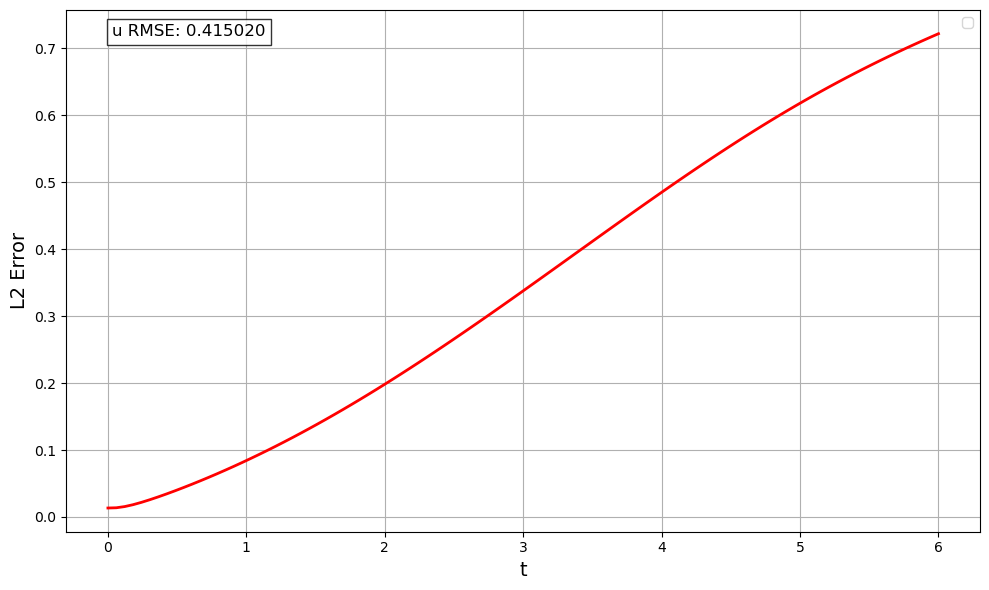

In [32]:
# 修改L2误差计算函数的x_range参数
def compute_and_plot_l2_error(u_analytical, u_predicted, t_points, x_range):
    """计算并绘制不同时间点上的L2误差"""
    # 计算空间步长(用于数值积分)
    dx = (x_range[1] - x_range[0]) / (u_analytical.shape[0] - 1)
    
    # 初始化L2误差数组
    l2_errors_u = np.zeros(len(t_points))
    
    # 对每个时间点计算L2误差
    for i in range(len(t_points)):
        # 计算u的L2误差
        squared_error_u = (u_analytical[:, i] - u_predicted[:, i])**2
        l2_errors_u[i] = np.sqrt(np.sum(squared_error_u) * dx)
    
    # 绘制L2误差随时间的变化
    plt.figure(figsize=(10, 6))
    plt.plot(t_points, l2_errors_u, 'r-', linewidth=2)
    plt.grid(True)
    plt.xlabel('t', fontsize=14)
    plt.ylabel('L2 Error', fontsize=14)
    plt.legend()
    
    # 添加均方根误差信息
    rmse_u = np.sqrt(np.mean(l2_errors_u**2))
    plt.text(0.05, 0.95, f'u RMSE: {rmse_u:.6f}', 
             transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return l2_errors_u

# 使用该函数计算并绘制L2误差
t_points = t.squeeze().numpy()  # 时间点数组
x_range = [-10, 10]  # 修改x的范围为[-10, 10]

# 计算并绘制L2误差
l2_errors_u = compute_and_plot_l2_error(
    u_analytical=u_exact, 
    u_predicted=u_pred,
    t_points=t_points,
    x_range=x_range
)